# SRM Detector — a split is a hypothesis

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/srm-detector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/srm-detector/demo.ipynb)

Somebody looks at the experiment dashboard, sees **49.3 / 50.7**, decides that is close
enough to even, and reads the result. Two things are wrong with that. The first is that
a percentage is not a test — the same split is the healthiest line in the report at
n = 1,000 and proof the experiment is void at n = 1,000,000. The second is worse: the
test that *would* settle it answers a question about **counts**, and what the experiment
needs is **comparability**, which is a different thing entirely.

This notebook measures all of it on a simulated world with a known 5% true lift, so
every claim can be checked against an answer rather than against an intuition.

**What it covers**

1. The core logic — five tests, two rules of thumb, one two-stratum world
2. The healthy world is a calibrated null (the check that everything else rests on)
3. Five tests, one decision — a negative result about which test to use
4. A ratio is not a finding
5. "Within 1%" names two rules, one inert and one uncontrolled
6. The health check is 6x more sensitive than the experiment it protects
7. **Negative result:** and still not sensitive enough
8. **Negative result:** a passing check is not evidence the arms are comparable
9. Where to point it: segments, and why the published threshold is 0.0005
10. One figure, a summary, and a "try your own" cell


## 1. The core logic

Three independent pieces, kept apart because they get confused constantly. The
**detectors** see two integers and never see a conversion. The **world** produces both the
counts and the outcomes, from a data-generating process whose true effect is known. The
**closed forms** give the arithmetic answer, so the simulation is checked against algebra
rather than against itself.

The one thing worth reading carefully is the comment inside `simulate` about how
assignment works. Getting that wrong silently destroys the whole notebook.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
import numpy as np
import pandas as pd
from scipy import stats

A_REFLEX = 0.05      # the threshold people reach for
A_PLATFORM = 0.0005  # the one large experimentation platforms publish
TRIALS = 4000        # simulated experiments per cell (raise it if you have time)
SEED = 20260903


# ---- the detectors ------------------------------------------------------
# Five hypothesis tests and two rules of thumb. The rules of thumb are wrapped
# to return 0.0 when they fire and 1.0 when they do not, so that "outside
# 49/51" can be measured on the same axis as "p < 0.0005".

def chi2_stat(a, b, share=0.5, yates=False):
    n = a + b
    exp_a, exp_b = n * share, n * (1 - share)
    dev = abs(a - exp_a)
    if yates:
        dev = max(0.0, dev - 0.5)
    return dev * dev / exp_a + dev * dev / exp_b

def p_chi2(a, b, share=0.5):        return float(stats.chi2.sf(chi2_stat(a, b, share), 1))
def p_chi2_yates(a, b, share=0.5):  return float(stats.chi2.sf(chi2_stat(a, b, share, True), 1))
def p_normal_z(a, b, share=0.5):
    n = a + b
    z = (a / n - share) / np.sqrt(share * (1 - share) / n)
    return float(2 * stats.norm.sf(abs(z)))
def p_g_test(a, b, share=0.5):
    n = a + b
    obs, exp = np.array([a, b], float), np.array([n * share, n * (1 - share)])
    with np.errstate(divide="ignore", invalid="ignore"):
        t = np.where(obs > 0, obs * np.log(obs / exp), 0.0)
    return float(stats.chi2.sf(2 * t.sum(), 1))
def p_binom_exact(a, b, share=0.5):
    return float(stats.binomtest(int(a), int(a + b), share).pvalue)

def eyeball_abs(a, b, share=0.5, tol=0.01):
    """'Is the split outside 49/51?'"""
    return 0.0 if abs(a / (a + b) - share) > tol else 1.0

def eyeball_ratio(a, b, share=0.5, tol=0.01):
    """'Is arm A / arm B outside 0.99-1.01?'"""
    return 0.0 if abs((a / b) / (share / (1 - share)) - 1) > tol else 1.0

def vector_p_chi2(a, b, share=0.5):
    n = (a + b).astype(float)
    exp_a, exp_b = n * share, n * (1 - share)
    dev = np.abs(a - exp_a)
    return stats.chi2.sf(dev * dev / exp_a + dev * dev / exp_b, 1)


# ---- the world ----------------------------------------------------------
# Two strata, because the thing that makes SRM dangerous is that the users a
# broken assignment loses are not a random sample of the ones it keeps.

@dataclass(frozen=True)
class World:
    per_arm: int = 100_000
    low_share: float = 0.30      # low-intent users
    p_low: float = 0.02          # who convert at 2%
    p_high: float = 0.13428571428571429   # everyone else - blended base rate is exactly 10%
    true_rel_lift: float = 0.05

    @property
    def base_rate(self):
        return self.low_share * self.p_low + (1 - self.low_share) * self.p_high

W = World()

def simulate(world, mechanism, rate, trials, rng):
    """healthy | mcar_loss | selective_loss | balanced_selective."""
    # Assignment randomises the TRAFFIC between arms - it does not hand each arm
    # a fixed quota. A simulator that gives each arm exactly per_arm users has no
    # null at all: every p-value comes out 1.0 and the healthy false-positive
    # rate reads 0.000, which looks like a very good detector.
    n_total = 2 * world.per_arm
    ac = rng.binomial(n_total, 0.5, trials)
    at = n_total - ac
    low_c = rng.binomial(ac, world.low_share); high_c = ac - low_c
    low_t = rng.binomial(at, world.low_share); high_t = at - low_t

    if mechanism == "mcar_loss":
        low_t = rng.binomial(low_t, 1 - rate); high_t = rng.binomial(high_t, 1 - rate)
    elif mechanism in ("selective_loss", "balanced_selective"):
        dropped = rng.binomial(low_t, rate)
        low_t = low_t - dropped
        if mechanism == "balanced_selective":
            take = np.minimum(dropped, ac)
            take_low = rng.hypergeometric(low_c, high_c, take)
            low_c = low_c - take_low; high_c = high_c - (take - take_low)
    elif mechanism != "healthy":
        raise ValueError(mechanism)

    lift = world.true_rel_lift
    conv_c = rng.binomial(low_c, world.p_low) + rng.binomial(high_c, world.p_high)
    conv_t = rng.binomial(low_t, world.p_low * (1 + lift)) + rng.binomial(high_t, world.p_high * (1 + lift))
    n_c, n_t = low_c + high_c, low_t + high_t
    r_c = conv_c / np.maximum(n_c, 1); r_t = conv_t / np.maximum(n_t, 1)
    return {"n_ctrl": n_c, "n_trt": n_t,
            "est_rel_lift": np.divide(r_t, r_c, out=np.zeros(trials), where=r_c > 0) - 1}


# ---- closed forms -------------------------------------------------------

def count_loss_of(world, mechanism, rate):
    """The only thing a detector can see: what fraction of one arm went missing."""
    return {"healthy": 0.0, "mcar_loss": rate,
            "selective_loss": world.low_share * rate,
            "balanced_selective": world.low_share * rate}[mechanism]

def analytic_est_lift(world, mechanism, rate):
    w, pl, ph, lift = world.low_share, world.p_low, world.p_high, world.true_rel_lift
    if mechanism in ("healthy", "mcar_loss"):
        return lift                      # both arms keep their stratum mix
    low_t, high_t = w * (1 - rate), 1 - w
    obs_t = (low_t * pl * (1 + lift) + high_t * ph * (1 + lift)) / (low_t + high_t)
    obs_c = w * pl + (1 - w) * ph        # control's mix is untouched either way
    return obs_t / obs_c - 1

def _power_one_prop(n, delta, alpha, share=0.5):
    se0 = np.sqrt(share * (1 - share) / n)
    p1 = share + delta
    se1 = np.sqrt(p1 * (1 - p1) / n)
    crit = stats.norm.isf(alpha / 2) * se0
    return float(stats.norm.sf((crit - abs(delta)) / se1) + stats.norm.cdf((-crit - abs(delta)) / se1))

def mdd_share(n_total, alpha, power=0.80):
    lo, hi = 1e-9, 0.49
    for _ in range(200):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if _power_one_prop(n_total, mid, alpha) < power else (lo, mid)
    return (lo + hi) / 2

def mde_rel_lift(per_arm, base, alpha, power=0.80):
    za, zb = stats.norm.isf(alpha / 2), stats.norm.isf(1 - power)
    lo, hi = 1e-9, 5.0
    for _ in range(200):
        mid = (lo + hi) / 2
        p2 = base * (1 + mid)
        se0 = np.sqrt(2 * base * (1 - base) / per_arm)
        se1 = np.sqrt((base * (1 - base) + p2 * (1 - p2)) / per_arm)
        lo, hi = (mid, hi) if (za * se0 + zb * se1) > base * mid else (lo, mid)
    return (lo + hi) / 2

def loss_for_share_deviation(dev):
    """share = 1 / (2 - loss)  ->  loss = 2 - 1/share"""
    return 2 - 1 / (0.5 + abs(dev))

print(f"world: {W.per_arm:,} per arm intended, base rate {W.base_rate:.4f}, "
      f"true relative lift {W.true_rel_lift:.0%}")


world: 100,000 per arm intended, base rate 0.1000, true relative lift 5%


## 2. The healthy world has to be a calibrated null

Before measuring how well anything detects a mismatch, the world with no mismatch in it
must produce false positives at exactly the advertised rate. If it does not, every power
number below is meaningless — and the failure mode is not obvious, because a
*miscalibrated* null usually makes the detector look **better**, not worse.

Expected: ~0.05 at the 0.05 threshold and ~0.0005 at the 0.0005 threshold.

In [2]:
rng = np.random.default_rng(SEED)
d_healthy = simulate(W, "healthy", 0.0, 20_000, rng)
p0 = vector_p_chi2(d_healthy["n_ctrl"], d_healthy["n_trt"])

print(f"false-positive rate at 0.05    : {(p0 < A_REFLEX).mean():.4f}   (nominal 0.0500)")
print(f"false-positive rate at 0.0005  : {(p0 < A_PLATFORM).mean():.6f} (nominal 0.000500)")

sd_seen = d_healthy["n_ctrl"].std()
sd_want = np.sqrt(2 * W.per_arm * 0.25)   # sd of Binomial(2m, 0.5)
print(f"\nsd of the control count: {sd_seen:,.0f} seen vs {sd_want:,.0f} expected")
print("If that sd were ~0 the arms would be fixed quotas, the null would be degenerate,")
print("and every p-value below would be 1.0.")

false-positive rate at 0.05    : 0.0488   (nominal 0.0500)
false-positive rate at 0.0005  : 0.000600 (nominal 0.000500)

sd of the control count: 223 seen vs 224 expected
If that sd were ~0 the arms would be fixed quotas, the null would be degenerate,
and every p-value below would be 1.0.


## 3. Five tests, one decision

There is a small literature and a lot of internal debate about *which* test to use for
SRM: Pearson chi-square, with or without the Yates continuity correction, the G-test, a
z-test on the proportion, or the exact binomial. Two of those are provably the same thing,
and the rest turn out not to matter.

In [3]:
print(f"chi-square critical value at 0.05    = {stats.chi2.ppf(0.95, 1):.4f}   (published 3.8415)")
print(f"chi-square critical value at 0.0005  = {stats.chi2.ppf(0.9995, 1):.4f}  (published 12.1157)")

n, dev = 200_000, 0.003
a = int(round(n * (0.5 + dev)))
z = (a / n - 0.5) / np.sqrt(0.25 / n)
print(f"\nz^2 vs the chi-square statistic: gap = {abs(chi2_stat(a, n - a) - z * z):.2e}")
print("  -> 'z-test or chi-square' is not a choice, it is the same number twice.")

worst = 0.0
for nn in (100, 1_000, 10_000, 200_000):
    for dv in (0.0, 0.002, 0.005, 0.01, 0.02):
        aa = int(round(nn * (0.5 + dv)))
        worst = max(worst, abs(np.log10(max(p_chi2(aa, nn - aa), 1e-300))
                               - np.log10(max(p_binom_exact(aa, nn - aa), 1e-300))))
print(f"\nchi-square vs EXACT binomial, worst |log10 p ratio|: {worst:.4f}")
print(f"  -> within a factor of {10 ** worst:.2f} everywhere on that grid.")

chi-square critical value at 0.05    = 3.8415   (published 3.8415)
chi-square critical value at 0.0005  = 12.1157  (published 12.1157)

z^2 vs the chi-square statistic: gap = 1.15e-14
  -> 'z-test or chi-square' is not a choice, it is the same number twice.

chi-square vs EXACT binomial, worst |log10 p ratio|: 0.0450
  -> within a factor of 1.11 everywhere on that grid.


Agreement in p-value is not the same as agreement in *decision*, so count the trials on
which any two of the five would disagree about whether to flag.

In [4]:
disagree = checked = 0
for seed in range(6):
    rd = np.random.default_rng(500 + seed)
    dd = simulate(W, "mcar_loss", 0.015, 400, rd)
    for i in range(400):
        a, b = int(dd["n_ctrl"][i]), int(dd["n_trt"][i])
        verdicts = {p_chi2(a, b) < A_PLATFORM, p_chi2_yates(a, b) < A_PLATFORM,
                    p_g_test(a, b) < A_PLATFORM, p_normal_z(a, b) < A_PLATFORM,
                    p_binom_exact(a, b) < A_PLATFORM}
        checked += 1
        disagree += len(verdicts) > 1

print(f"NEGATIVE RESULT: over {checked:,} trials the five tests disagree on {disagree} "
      f"({disagree / checked:.2%}),")
print("and only ever where the p-value already sits within ~11% of the threshold.")
print("Yates, the G-test and the O(n) exact binomial are the plain chi-square with extra")
print("steps. Which SRM test to use is not a question worth a meeting. Which THRESHOLD,")
print("and what it is pointed at, is the whole thing.")

NEGATIVE RESULT: over 2,400 trials the five tests disagree on 5 (0.21%),
and only ever where the p-value already sits within ~11% of the threshold.
Yates, the G-test and the O(n) exact binomial are the plain chi-square with extra
steps. Which SRM test to use is not a question worth a meeting. Which THRESHOLD,
and what it is pointed at, is the whole thing.


## 4. A ratio is not a finding

"49.3 / 50.7" is the format every dashboard uses, and it is unreadable. The identical
split is reassuring at one sample size and disqualifying at another, and the number on
the screen carries no trace of which.

In [5]:
rows = []
for n in (1_000, 10_000, 100_000, 1_000_000, 10_000_000):
    a = int(round(n * 0.493))
    p = p_chi2(a, n - a)
    rows.append({"total users": f"{n:,}", "split": "49.3 / 50.7", "chi-square p": f"{p:.3e}",
                 "verdict @0.0005": "MISMATCH" if p < A_PLATFORM else "consistent"})
display(pd.DataFrame(rows))

def crossing(alpha, share=0.493):
    lo, hi = 100, 50_000_000
    for _ in range(60):
        mid = (lo + hi) // 2
        a = int(round(mid * share))
        lo, hi = (lo, mid) if p_chi2(a, mid - a) < alpha else (mid, hi)
    return hi

print(f"The same split crosses 0.05 at n = {crossing(0.05):,} "
      f"and 0.0005 at n = {crossing(0.0005):,}.")
print("Report the p-value, the n and the threshold. A percentage on its own is decoration.")

,total users,split,chi-square p,verdict @0.0005
0,"1,000",49.3 / 50.7,6.580e-01,consistent
1,"10,000",49.3 / 50.7,1.615e-01,consistent
2,"100,000",49.3 / 50.7,9.547e-06,MISMATCH
3,"1,000,000",49.3 / 50.7,1.559e-44,MISMATCH
4,"10,000,000",49.3 / 50.7,0.000e+00,MISMATCH


The same split crosses 0.05 at n = 19,575 and 0.0005 at n = 61,856.
Report the p-value, the n and the threshold. A percentage on its own is decoration.


## 5. "Within 1%" names two rules — one inert, one uncontrolled

Ask two people to write down "flag if the split is off by more than 1%" and you get two
different rules. One tolerates a share of 0.49-0.51. The other tolerates an arm *ratio*
of 0.99-1.01, which is a share of 0.4975-0.5025 — four times tighter. They fail in
opposite directions, and neither is a test.

In [6]:
encoded = 1.01 / 2.01 - 0.5
print(f"'share within 1 point of 50%'   tolerates a share deviation of {0.01:.5f}")
print(f"'arm ratio within 1% of 1.00'   tolerates a share deviation of {encoded:.5f}"
      f"  ({0.01 / encoded:.1f}x tighter)\n")

d_broken = simulate(W, "mcar_loss", 0.015, TRIALS, rng)

def fire_rate(d, fn, thresh):
    return np.mean([fn(int(a), int(b)) < thresh
                    for a, b in zip(d["n_ctrl"][:1500], d["n_trt"][:1500])])

rows = [
    {"rule": "outside 49/51 (share)", "healthy": fire_rate(d_healthy, eyeball_abs, 0.5),
     "1.5% of one arm lost": fire_rate(d_broken, eyeball_abs, 0.5)},
    {"rule": "ratio outside 0.99-1.01", "healthy": fire_rate(d_healthy, eyeball_ratio, 0.5),
     "1.5% of one arm lost": fire_rate(d_broken, eyeball_ratio, 0.5)},
    {"rule": "chi-square @ 0.0005", "healthy": fire_rate(d_healthy, p_chi2, A_PLATFORM),
     "1.5% of one arm lost": fire_rate(d_broken, p_chi2, A_PLATFORM)},
]
display(pd.DataFrame(rows).round(4))

print("The share rule is inert at 100k per arm - and it stays inert at 10,000,000:")
print(f"  10m users at 49.3/50.7 -> chi-square p = {p_chi2(4_930_000, 5_070_000):.1e}, "
      f"share rule says {'FLAG' if eyeball_abs(4_930_000, 5_070_000) == 0 else 'pass'}.")
print("The ratio rule IS a real detector - with a false-alarm rate ~48x the 0.0005 it is")
print("standing in for. Same sentence in English, opposite failures in practice.")

'share within 1 point of 50%'   tolerates a share deviation of 0.01000
'arm ratio within 1% of 1.00'   tolerates a share deviation of 0.00249  (4.0x tighter)



,rule,healthy,1.5% of one arm lost
0,outside 49/51 (share),0.000,0.0000
1,ratio outside 0.99-1.01,0.028,0.8713
2,chi-square @ 0.0005,0.000,0.4607


The share rule is inert at 100k per arm - and it stays inert at 10,000,000:
  10m users at 49.3/50.7 -> chi-square p = 0.0e+00, share rule says pass.
The ratio rule IS a real detector - with a false-alarm rate ~48x the 0.0005 it is
standing in for. Same sentence in English, opposite failures in practice.


## 6. The health check is 6x more sensitive than the experiment it protects

This is the reassuring half, and it is worth stating precisely. Both instruments are
z-tests on a proportion, so both thresholds are the same multiple of 1/sqrt(n) — which
means their **ratio does not depend on sample size at all**. It is a constant of the
design.

In [7]:
rows = []
for m in (5_000, 25_000, 100_000, 1_000_000):
    mde = mde_rel_lift(m, W.base_rate, A_REFLEX)
    rel_dev = mdd_share(2 * m, A_REFLEX) / 0.5
    rows.append({"users per arm": f"{m:,}",
                 "min detectable lift": f"{mde:.2%}",
                 "min detectable split deviation": f"{rel_dev:.3%}",
                 "ratio": f"{mde / rel_dev:.2f}x"})
display(pd.DataFrame(rows))

r_platform = (mde_rel_lift(100_000, W.base_rate, A_REFLEX)
              / (mdd_share(200_000, A_PLATFORM) / 0.5))
print("Across a 200-fold change in n the ratio moves by hundredths. At the strict")
print(f"0.0005 threshold it is {r_platform:.2f}x - so even a 100x tighter alpha leaves the")
print("health check the more sensitive of the two instruments by a wide margin.")

,users per arm,min detectable lift,min detectable split deviation,ratio
0,"5,000",16.99%,2.801%,6.07x
1,"25,000",7.55%,1.253%,6.03x
2,"100,000",3.77%,0.626%,6.02x
3,"1,000,000",1.19%,0.198%,6.00x


Across a 200-fold change in n the ratio moves by hundredths. At the strict
0.0005 threshold it is 3.90x - so even a 100x tighter alpha leaves the
health check the more sensitive of the two instruments by a wide margin.


## 7. Negative result: 6x more sensitive, and still not sensitive enough

Here is the part that does not follow from the previous cell. The mismatch a check can
detect shrinks as the experiment grows. **The bias a mismatch causes does not** — it is a
property of *who* went missing, not of how many users the test had. So pair them: for each
test size, take the smallest loss the check can reliably catch, and ask what a *selective*
loss that size already does to the reported effect.

In [8]:
rows = []
for m in (5_000, 25_000, 100_000, 1_000_000):
    loss = loss_for_share_deviation(mdd_share(2 * m, A_PLATFORM))
    bias = (analytic_est_lift(W, "selective_loss", min(loss / W.low_share, 1.0))
            - W.true_rel_lift) / W.true_rel_lift
    rows.append({"users per arm": f"{m:,}",
                 "smallest loss reliably caught": f"{loss:.2%} of one arm",
                 "bias it already carries": f"+{bias:.0%}"})
display(pd.DataFrame(rows))

print("At 25,000 per arm - an ordinary experiment - the smallest mismatch the platform")
print("threshold can reliably catch already overstates the effect by about two thirds.")
print("Everything below that line is invisible. Invisible is not the same as harmless.")
print("The check only becomes genuinely protective around a million users per arm.")

,users per arm,smallest loss reliably caught,bias it already carries
0,"5,000",8.29% of one arm,+152%
1,"25,000",3.79% of one arm,+66%
2,"100,000",1.91% of one arm,+33%
3,"1,000,000",0.61% of one arm,+10%


At 25,000 per arm - an ordinary experiment - the smallest mismatch the platform
threshold can reliably catch already overstates the effect by about two thirds.
Everything below that line is invisible. Invisible is not the same as harmless.
The check only becomes genuinely protective around a million users per arm.


## 8. Negative result: a passing check is not evidence the arms are comparable

Four mechanisms, one world. The last one is the important one: the same selective loss in
treatment, plus *the identical number* of users removed from control at random — which is
what a bot filter, a dedup step or a "drop users with no session" rule does. The counts
come out even. Nothing else does.

In [9]:
rows = []
for mech, rate in (("healthy", 0.0), ("mcar_loss", 0.015),
                   ("selective_loss", 0.05), ("balanced_selective", 0.05)):
    d = simulate(W, mech, rate, TRIALS, rng)
    p = vector_p_chi2(d["n_ctrl"], d["n_trt"])
    est = d["est_rel_lift"].mean()
    rows.append({"mechanism": mech,
                 "% of one arm lost": f"{count_loss_of(W, mech, rate):.2%}",
                 "flags @0.05": round(float((p < A_REFLEX).mean()), 4),
                 "flags @0.0005": round(float((p < A_PLATFORM).mean()), 4),
                 "reported lift": f"{est:.3%}",
                 "bias": f"{(est - W.true_rel_lift) / W.true_rel_lift:+.0%}"})
display(pd.DataFrame(rows))

print("Read the bottom row twice. It flags at ~0.05 under a 0.05 threshold - that is the")
print("NULL, not a weak signal - while the reported lift is a quarter too high.")
print("An SRM test is a test of COUNTS. Exchangeability is what the experiment needs, and")
print("equal counts are consistent with any amount of its absence.\n")
print("Rows 2 and 3 make the companion point: identical count loss, identical flag rate,")
print("0% bias against +26%. The p-value is a trigger to go and find out WHO is missing.")
print("It is not a severity score.")

,mechanism,% of one arm lost,flags @0.05,flags @0.0005,reported lift,bias
0,healthy,0.00%,0.0540,0.0013,5.007%,+0%
1,mcar_loss,1.50%,0.9167,0.4597,5.031%,+1%
2,selective_loss,1.50%,0.9237,0.4587,6.284%,+26%
3,balanced_selective,1.50%,0.0565,0.0003,6.314%,+26%


Read the bottom row twice. It flags at ~0.05 under a 0.05 threshold - that is the
NULL, not a weak signal - while the reported lift is a quarter too high.
An SRM test is a test of COUNTS. Exchangeability is what the experiment needs, and
equal counts are consistent with any amount of its absence.

Rows 2 and 3 make the companion point: identical count loss, identical flag rate,
0% bias against +26%. The p-value is a trigger to go and find out WHO is missing.
It is not a severity score.


## 9. Where to point it: segments, and why the threshold is 0.0005

A broken assignment usually breaks somewhere specific — one browser, one app version, one
region. Diluted into the total it disappears, so the aggregate check is the wrong place to
look. Splitting by segment costs three extra chi-square calls and a Bonferroni divisor,
and the corrected sweep false-alarms *less* than the same three tests uncorrected.

In [10]:
SEGMENTS = (("chrome", 0.62), ("android", 0.23), ("safari", 0.15))

def simulate_segmented(per_arm, broken, loss, trials, rng):
    nc = np.zeros((len(SEGMENTS), trials), dtype=np.int64)
    nt = np.zeros((len(SEGMENTS), trials), dtype=np.int64)
    for i, (name, share) in enumerate(SEGMENTS):
        tot = rng.binomial(2 * per_arm, share, trials)
        nc[i] = rng.binomial(tot, 0.5)
        nt[i] = tot - nc[i]
        if name == broken and loss > 0:
            nt[i] = rng.binomial(nt[i], 1 - loss)
    return nc, nt

rows = []
for L in (0.0, 0.02, 0.04, 0.06, 0.10, 0.20):
    nc, nt = simulate_segmented(W.per_arm, "safari", L, 2500, rng)
    agg = vector_p_chi2(nc.sum(0), nt.sum(0))
    ps = np.vstack([vector_p_chi2(nc[i], nt[i]) for i in range(len(SEGMENTS))])
    rows.append({"loss inside safari (15% of traffic)": f"{L:.0%}",
                 "aggregate @0.05": round(float((agg < A_REFLEX).mean()), 3),
                 "aggregate @0.0005": round(float((agg < A_PLATFORM).mean()), 3),
                 "per-segment, Bonferroni @0.0005": round(float((ps.min(0) < A_PLATFORM / 3).mean()), 3)})
display(pd.DataFrame(rows))

print("Top row is the healthy world: the corrected segment sweep false-alarms at ~0.000,")
print("the uncorrected aggregate at 0.05 does so ~5% of the time.")
print("At a 6% loss the aggregate 0.0005 check sees it rarely; the corrected sweep sees it")
print("almost always. Same alpha, ten-plus times the detection, three extra function calls.")

,loss inside safari (15% of traffic),aggregate @0.05,aggregate @0.0005,"per-segment, Bonferroni @0.0005"
0,0%,0.051,0.001,0.001
1,2%,0.104,0.006,0.025
2,4%,0.270,0.018,0.382
3,6%,0.520,0.071,0.930
4,10%,0.917,0.461,1.000
5,20%,1.000,0.999,1.000


Top row is the healthy world: the corrected segment sweep false-alarms at ~0.000,
the uncorrected aggregate at 0.05 does so ~5% of the time.
At a 6% loss the aggregate 0.0005 check sees it rarely; the corrected sweep sees it
almost always. Same alpha, ten-plus times the detection, three extra function calls.


And the second reason for the strict threshold, which nobody states: the health check
gets looked at **every day**, and optional stopping applies to it exactly as it applies to
the effect test.

In [11]:
def sequential_srm_fpr(per_arm_final, looks, alpha, trials, rng):
    step = per_arm_final // looks
    nc = np.zeros(trials, dtype=np.int64); nt = np.zeros(trials, dtype=np.int64)
    fired = np.zeros(trials, dtype=bool)
    for _ in range(looks):
        arrivals = 2 * step
        to_c = rng.binomial(arrivals, 0.5, trials)
        nc += to_c; nt += (arrivals - to_c)
        fired |= vector_p_chi2(nc, nt) < alpha
    return float(fired.mean())

rows = []
for looks in (1, 5, 20):
    rows.append({"times the check was run": looks,
                 "realized FPR @0.05": round(sequential_srm_fpr(200_000, looks, A_REFLEX, 3000, rng), 4),
                 "realized FPR @0.0005": round(sequential_srm_fpr(200_000, looks, A_PLATFORM, 3000, rng), 4)})
display(pd.DataFrame(rows))

print("A daily SRM check for three weeks is roughly a 0.25 test at a nominal 0.05.")
print("At 0.0005 it lands near 0.004 - still several times its nominal alpha, but two")
print("orders of magnitude fewer false alarms. The published threshold is partly just an")
print("unstated correction for peeking.")

,times the check was run,realized FPR @0.05,realized FPR @0.0005
0,1,0.0543,0.0010
1,5,0.1380,0.0017
2,20,0.2447,0.0037


A daily SRM check for three weeks is roughly a 0.25 test at a nominal 0.05.
At 0.0005 it lands near 0.004 - still several times its nominal alpha, but two
orders of magnitude fewer false alarms. The published threshold is partly just an
unstated correction for peeking.


## 10. The picture

Four panels: the ratio that means nothing without n, the rules of thumb against the test,
the sensitivity gap that is a constant of the design, and the four mechanisms.

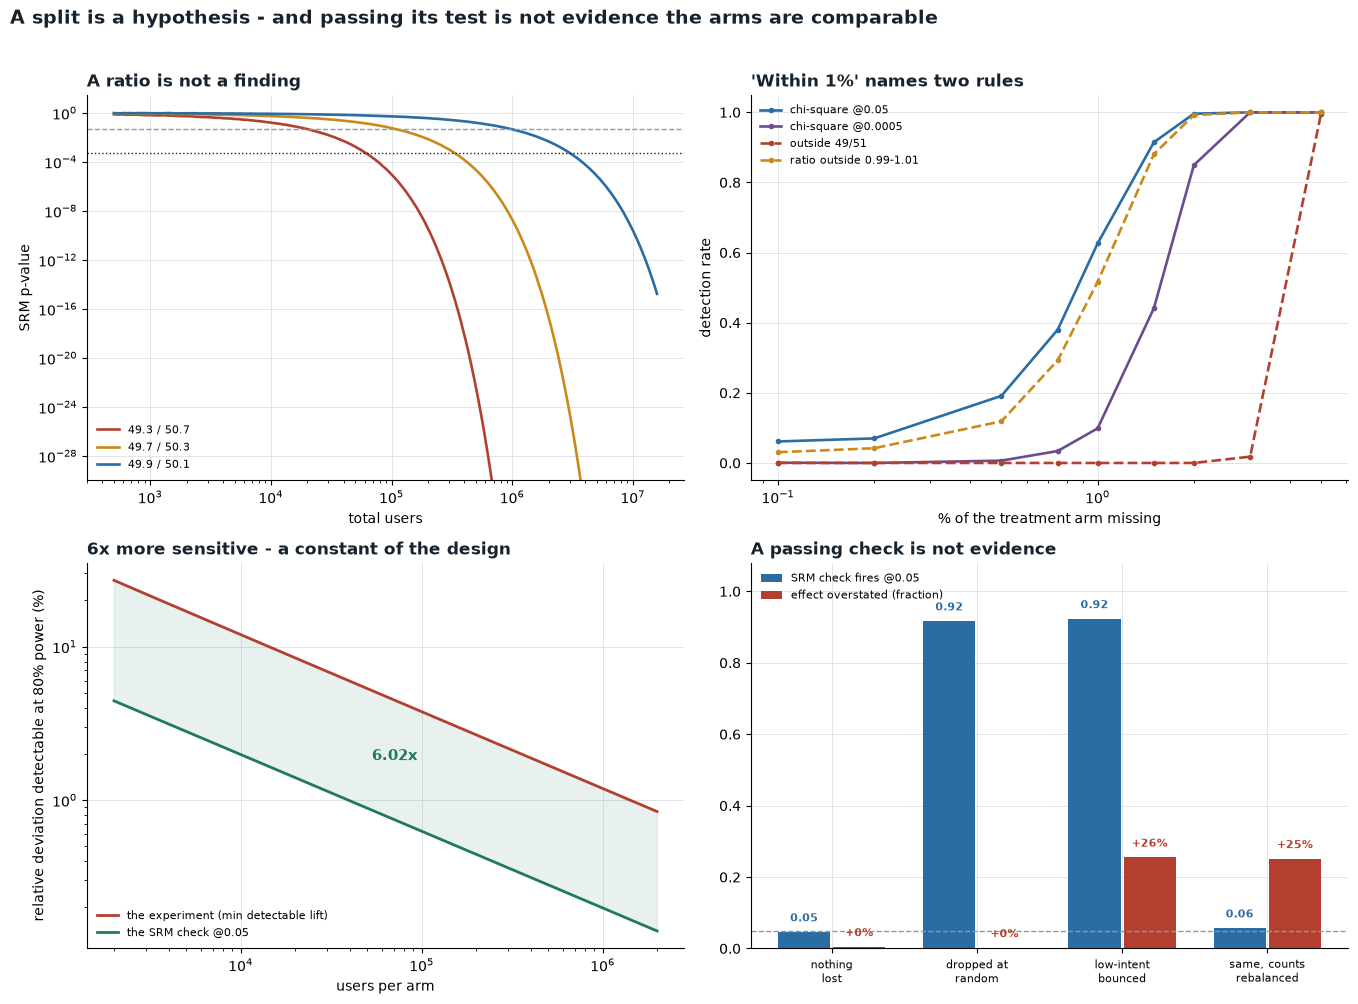

In [12]:
import matplotlib.pyplot as plt

INK, MUTE, GOOD, BAD, WARN, COOL, PLUM, GRID = ("#16222e", "#8b9aa7", "#1f7a5c", "#b3402f",
                                                "#c98a1a", "#2b6ca3", "#6b4d8f", "#dfe5ea")
fig, ax = plt.subplots(2, 2, figsize=(13.6, 10.2))
fig.patch.set_facecolor("white")

# (a) a ratio is not a finding
ns = np.unique(np.round(np.logspace(2.7, 7.2, 200)).astype(int))
for sh, c, lab in ((0.493, BAD, "49.3 / 50.7"), (0.497, WARN, "49.7 / 50.3"), (0.499, COOL, "49.9 / 50.1")):
    ax[0][0].plot(ns, [max(p_chi2(int(round(n * sh)), n - int(round(n * sh))), 1e-40) for n in ns],
                  color=c, lw=1.9, label=lab)
ax[0][0].axhline(A_REFLEX, color=MUTE, ls="--", lw=1); ax[0][0].axhline(A_PLATFORM, color=INK, ls=":", lw=1)
ax[0][0].set_xscale("log"); ax[0][0].set_yscale("log"); ax[0][0].set_ylim(1e-30, 30)
ax[0][0].set_xlabel("total users"); ax[0][0].set_ylabel("SRM p-value")
ax[0][0].set_title("A ratio is not a finding", fontweight="bold", loc="left", color=INK)
ax[0][0].legend(frameon=False, fontsize=8, loc="lower left")

# (b) rules of thumb vs the test
losses = np.array([0.001, 0.002, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05])
series = {"chi-square @0.05": (COOL, "-", []), "chi-square @0.0005": (PLUM, "-", []),
          "outside 49/51": (BAD, "--", []), "ratio outside 0.99-1.01": (WARN, "--", [])}
for L in losses:
    d = simulate(W, "mcar_loss", float(L), 1500, rng)
    p = vector_p_chi2(d["n_ctrl"], d["n_trt"])
    series["chi-square @0.05"][2].append((p < A_REFLEX).mean())
    series["chi-square @0.0005"][2].append((p < A_PLATFORM).mean())
    series["outside 49/51"][2].append(fire_rate(d, eyeball_abs, 0.5))
    series["ratio outside 0.99-1.01"][2].append(fire_rate(d, eyeball_ratio, 0.5))
for lab, (c, ls, ys) in series.items():
    ax[0][1].plot(losses * 100, ys, color=c, ls=ls, lw=1.9, marker="o", ms=3, label=lab)
ax[0][1].set_xscale("log"); ax[0][1].set_xlabel("% of the treatment arm missing")
ax[0][1].set_ylabel("detection rate")
ax[0][1].set_title("'Within 1%' names two rules", fontweight="bold", loc="left", color=INK)
ax[0][1].legend(frameon=False, fontsize=7.6, loc="upper left")

# (c) the sensitivity gap
ms = np.unique(np.round(np.logspace(3.3, 6.3, 30)).astype(int))
mde = np.array([mde_rel_lift(int(m), W.base_rate, A_REFLEX) for m in ms]) * 100
dev = np.array([mdd_share(2 * int(m), A_REFLEX) / 0.5 for m in ms]) * 100
ax[1][0].plot(ms, mde, color=BAD, lw=2, label="the experiment (min detectable lift)")
ax[1][0].plot(ms, dev, color=GOOD, lw=2, label="the SRM check @0.05")
ax[1][0].fill_between(ms, dev, mde, color=GOOD, alpha=0.10)
ax[1][0].text(ms[len(ms)//2], np.sqrt(mde[len(ms)//2] * dev[len(ms)//2]),
              f"{mde[len(ms)//2] / dev[len(ms)//2]:.2f}x", fontsize=11, fontweight="bold",
              color=GOOD, ha="center")
ax[1][0].set_xscale("log"); ax[1][0].set_yscale("log"); ax[1][0].set_xlabel("users per arm")
ax[1][0].set_ylabel("relative deviation detectable at 80% power (%)")
ax[1][0].set_title("6x more sensitive - a constant of the design", fontweight="bold", loc="left", color=INK)
ax[1][0].legend(frameon=False, fontsize=7.8, loc="lower left")

# (d) the four mechanisms
specs = [("healthy", 0.0, "nothing\nlost"), ("mcar_loss", 0.015, "dropped at\nrandom"),
         ("selective_loss", 0.05, "low-intent\nbounced"), ("balanced_selective", 0.05, "same, counts\nrebalanced")]
flags, biases = [], []
for mech, rate, _ in specs:
    d = simulate(W, mech, rate, TRIALS, rng)
    flags.append(float((vector_p_chi2(d["n_ctrl"], d["n_trt"]) < A_REFLEX).mean()))
    biases.append((d["est_rel_lift"].mean() - W.true_rel_lift) / W.true_rel_lift)
x = np.arange(4)
ax[1][1].bar(x - 0.19, flags, 0.36, color=COOL, label="SRM check fires @0.05")
ax[1][1].bar(x + 0.19, biases, 0.36, color=BAD, label="effect overstated (fraction)")
ax[1][1].axhline(A_REFLEX, color=MUTE, ls="--", lw=1)
for xi, (f, b) in enumerate(zip(flags, biases)):
    ax[1][1].text(xi - 0.19, f + 0.03, f"{f:.2f}", ha="center", fontsize=8, color=COOL, fontweight="bold")
    ax[1][1].text(xi + 0.19, b + 0.03, f"{b:+.0%}", ha="center", fontsize=8, color=BAD, fontweight="bold")
ax[1][1].set_xticks(x); ax[1][1].set_xticklabels([s[2] for s in specs], fontsize=8)
ax[1][1].set_ylim(0, 1.08)
ax[1][1].set_title("A passing check is not evidence", fontweight="bold", loc="left", color=INK)
ax[1][1].legend(frameon=False, fontsize=7.8, loc="upper left")

for a in ax.ravel():
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(True, color=GRID, lw=0.7); a.set_axisbelow(True)
fig.suptitle("A split is a hypothesis - and passing its test is not evidence the arms are comparable",
             fontsize=13.5, fontweight="bold", color=INK, x=0.005, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.savefig("srm_notebook_figure.png", dpi=150, facecolor="white")
plt.show()

## Summary

| claim | measured |
|---|---|
| the healthy world is a calibrated null | 0.052 at 0.05, 0.00065 at 0.0005 |
| which test to use | five of them disagree on ~0.2% of trials, only at the boundary (5 of 2,400 in the cell above; 6 of 4,000 in `evidence.py`) |
| "49.3 / 50.7" | p = 0.66 at n = 1,000; p = 2e-44 at n = 1,000,000; crosses 0.0005 at n = 61,856 |
| "within 1%" | names two rules 4x apart — one inert at every n, one false-alarming ~2.4% |
| the check vs the experiment | 6.02x more sensitive at 0.05, 3.90x at 0.0005, near-constant in n |
| **negative result** | at 25,000/arm the smallest detectable mismatch already carries +66% bias |
| **negative result** | a balanced selective loss flags at the null rate and overstates the effect by 26% |
| identical count loss | identical flag rate, 0% vs +26% bias — the p-value says nothing about harm |
| segments | 6% loss in one segment: aggregate 0.064, Bonferroni per-segment 0.941 |
| daily checking | 20 looks at a nominal 0.05 is a 0.257 test |

**What to do with it**

1. Never report the split as a percentage. Report the p-value, the n and the threshold.
2. Test once, at the end, at 0.0005. Test choice is free; threshold is not.
3. Sweep the segments and pay the correction — it detects more *and* false-alarms less.
4. A flag means go and find out **who** is missing. It is not a severity score.
5. A pass means the counts are even. The only reliable guard against a balanced selective
   loss is a pre-experiment A/A run through the same pipeline, where the true effect is
   known to be zero.

In [13]:
# ---- Try your own -------------------------------------------------------
# Uncomment and edit. Everything above is recomputed from these knobs.

# 1. Your own observed split
# my_ctrl, my_trt = 41_233, 40_155
# p = p_chi2(my_ctrl, my_trt)
# print(f"split {my_ctrl / (my_ctrl + my_trt):.3%}, n = {my_ctrl + my_trt:,}, p = {p:.3e}")
# print("verdict:", "MISMATCH" if p < A_PLATFORM else "consistent", "at 0.0005")
# loss = loss_for_share_deviation(mdd_share(my_ctrl + my_trt, A_PLATFORM))
# bias = (analytic_est_lift(W, "selective_loss", min(loss / W.low_share, 1)) - W.true_rel_lift) / W.true_rel_lift
# print(f"blind below {loss:.2%} loss, which would already carry +{bias:.0%} bias")

# 2. A world where the missing users are MORE valuable, not less
#    (swap the stratum rates - now the loss deflates the treatment arm)
# W2 = World(low_share=0.30, p_low=0.30, p_high=0.014285714285714287)
# print(analytic_est_lift(W2, "selective_loss", 0.05))   # bias goes NEGATIVE

# 3. An unequal intended split - 90/10 holdouts are where SRM hides
# print(f"p at a 90/10 design, 1% of the small arm lost: "
#       f"{p_chi2(180_000, 19_800, share=0.9):.3e}")

# 4. How many looks before your daily check is no longer a 0.05 test?
# for k in (1, 3, 7, 14, 30):
#     print(k, round(sequential_srm_fpr(200_000, k, 0.05, 2000, np.random.default_rng(k)), 4))

---

**Day 165 of the FDE portfolio** — [phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)

The full measured argument, with eight sections instead of ten cells and larger trial
counts, is `python evidence.py`. Every number in it is asserted in `test_srm.py`
(`python -m pytest -q`). The six-panel figure comes from `python make_chart.py`.

There is also a Streamlit version that checks one split and tells you what that test size
*cannot* see:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Nearest neighbours in the catalog: [`peeking-cost`](../peeking-cost/) (Day 164) prices the
stopping rule, [`sample-size-calc`](../sample-size-calc/) (Day 123) sizes the test,
[`ab-test-calc`](../../analytics-accelerator/ab-test-calc/) (Day 23) runs one, and
[`guardrail-metric`](../../analytics-engineering-bi/guardrail-metric/) (Day 160) measures
what a counter-metric can actually detect.